# DSC 630 Course Project

Catherine (Caitie) Schrotberger

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
#Import Dataset
CA = pd.read_csv("G:/My Drive/College/Caitie/DSC630-T302/Project/FILES/CA.csv")

In [2]:
#Drop redundant fields and reorder and provide sample data
#Drop Federal tax rate since it has been stable since 1993
CA = CA.drop(['Seq','state'], axis=1)
CA = CA[['Date', 'Gallons_Sold', 'Retail Prices', 'CA_Tax_Rate', 'GEPUCURRENT']]
CA['Gallons_Sold'] = CA['Gallons_Sold'].str.replace(',', '').astype(float)
CA.head(5)

,Date,Gallons_Sold,Retail Prices,CA_Tax_Rate,GEPUCURRENT
0,Jan-12,1.166817e+09,3.747,0.395,155.2511
1,Feb-12,1.156428e+09,4.027,0.395,142.0827
2,Mar-12,1.239604e+09,4.414,0.395,133.4523
3,Apr-12,1.188733e+09,4.292,0.395,130.9089
4,May-12,1.279635e+09,4.353,0.395,160.4999


array([[<Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>]], dtype=object)

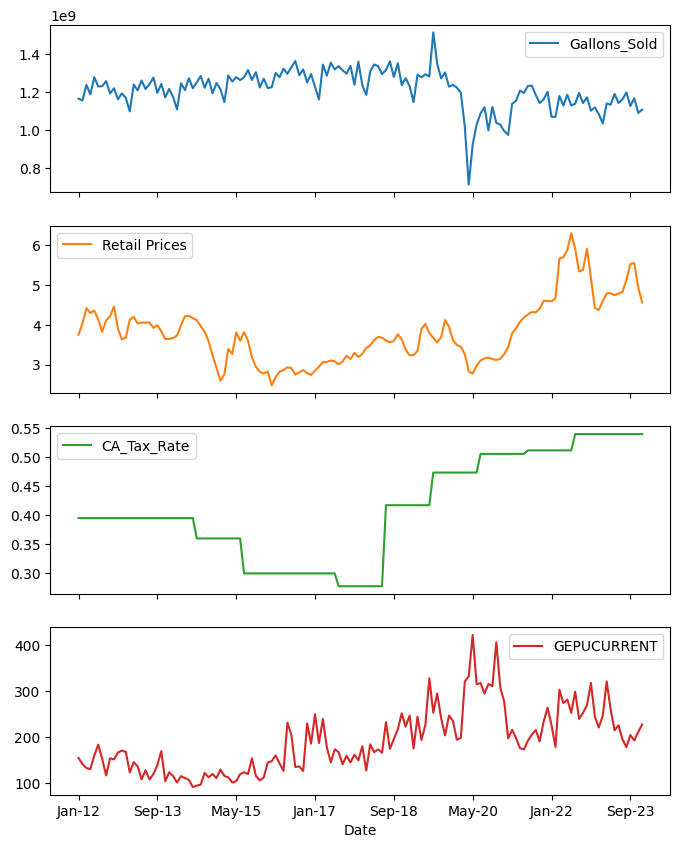

In [3]:
#Graph California Variables over time
CA.plot(x='Date', subplots=True, layout=(len(CA.columns)-1, 1), figsize=(8, 10), sharex=True)

In [4]:
#Find correlation matrix
corr_matrix_CA = CA[['Gallons_Sold', 'Retail Prices', 'CA_Tax_Rate', 'GEPUCURRENT']].corr()
print(corr_matrix_CA)

               Gallons_Sold  Retail Prices  CA_Tax_Rate  GEPUCURRENT
Gallons_Sold       1.000000      -0.219050    -0.593143    -0.479213
Retail Prices     -0.219050       1.000000     0.666901     0.186847
CA_Tax_Rate       -0.593143       0.666901     1.000000     0.597674
GEPUCURRENT       -0.479213       0.186847     0.597674     1.000000


In [5]:
#Evaluate if the tax rate impacts any of the variables using linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
# Train-test split
X_CA = CA[['Retail Prices', 'Gallons_Sold', 'GEPUCURRENT']]
y_CA = CA['CA_Tax_Rate']
X_train_CA, X_test_CA, y_train_CA, y_test_CA = train_test_split(X_CA, y_CA, test_size=0.2, random_state=42)
# Fit model and create predictions
model_CA = LinearRegression()
model_CA.fit(X_train_CA, y_train_CA)
y_pred_CA = model_CA.predict(X_test_CA)
lin_importance_CA = model_CA.coef_
linreg_r2_CA = r2_score(y_test_CA, y_pred_CA)
linreg_RMSE_CA = mean_squared_error(y_test_CA, y_pred_CA)
print("R^2 Score (CA):", linreg_r2_CA)
print("RMSE (CA):", linreg_RMSE_CA)

R^2 Score (CA): 0.768873271941942
RMSE (CA): 0.001744708338304841


In [6]:
#For correlated variables trying ridge and lasso models.
from sklearn.linear_model import Ridge, Lasso
ridge_CA = Ridge(alpha=1.0)
y_ridge_CA = ridge_CA.fit(X_train_CA, y_train_CA)
ridge_r2_CA = ridge_CA.score(X_test_CA, y_test_CA)
print("Ridge R^2 (CA):", ridge_r2_CA)
lasso_CA = Lasso(alpha=0.01)
y_lasso_CA=lasso_CA.fit(X_train_CA, y_train_CA)
y_lasso_pred_CA = lasso_CA.predict(X_test_CA)
lasso_importance_CA = lasso_CA.coef_
lasso_r2_CA =  lasso_CA.score(X_test_CA, y_test_CA)
lasso_RMSE_CA = mean_squared_error(y_test_CA, y_lasso_pred_CA)
print("R^2 Lasso (CA):", lasso_r2_CA)
print("RMSE Lasso (CA):", lasso_RMSE_CA)

Ridge R^2 (CA): 0.7687776621105264
R^2 Lasso (CA): 0.7495315251895909
RMSE Lasso (CA): 0.001890713549903436


C:\Users\caiti\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.00376e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [7]:
#Random Forests are great when relationships are messy and not strictly linear.
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_CA = rf.fit(X_train_CA, y_train_CA)
y_rf_pred_CA = rf.predict(X_test_CA)
rf_importance_CA = rf_model_CA.feature_importances_
rf_r2_CA = r2_score(y_test_CA, y_rf_pred_CA)
rf_RMSE_CA = mean_squared_error(y_test_CA, y_rf_pred_CA)
print("Random Forest R^2:", rf_r2_CA)
print("RMSE (Random Forest, CA):", rf_RMSE_CA)

Random Forest R^2: 0.8891965229542139
RMSE (Random Forest, CA): 0.0008364231689655162


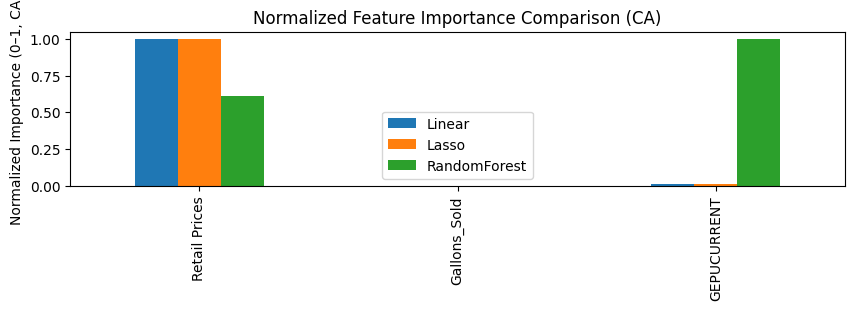

In [8]:
# Displaying normalized importance values
from sklearn.preprocessing import MinMaxScaler
scaler_CA = MinMaxScaler()
all_importances_CA = pd.DataFrame({"Linear": lin_importance_CA,
                                   "Lasso": lasso_importance_CA,
                                   "RandomForest": rf_importance_CA}, index=X_CA.columns)
normalized_CA = pd.DataFrame(scaler_CA.fit_transform(all_importances_CA),columns=all_importances_CA.columns,
                             index=all_importances_CA.index)
normalized_CA.plot(kind="bar", figsize=(10,2))
plt.title("Normalized Feature Importance Comparison (CA)")
plt.ylabel("Normalized Importance (0–1, CA)")
plt.show()

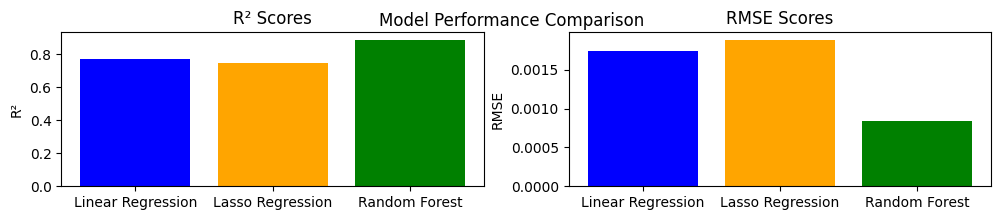

In [9]:
# Plot all R2 and RMSE side by side
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression", "Random Forest"],
    "R2": [linreg_r2_CA, lasso_r2_CA, rf_r2_CA],
    "RMSE": [linreg_RMSE_CA, lasso_RMSE_CA, rf_RMSE_CA]})
fig, ax = plt.subplots(1, 2, figsize=(12,2))
ax[0].bar(results["Model"], results["R2"], color=["blue","orange","green"])
ax[0].set_title("R² Scores")
ax[0].set_ylabel("R²")
ax[1].bar(results["Model"], results["RMSE"], color=["blue","orange","green"])
ax[1].set_title("RMSE Scores")
ax[1].set_ylabel("RMSE")
plt.suptitle("Model Performance Comparison")
plt.show()

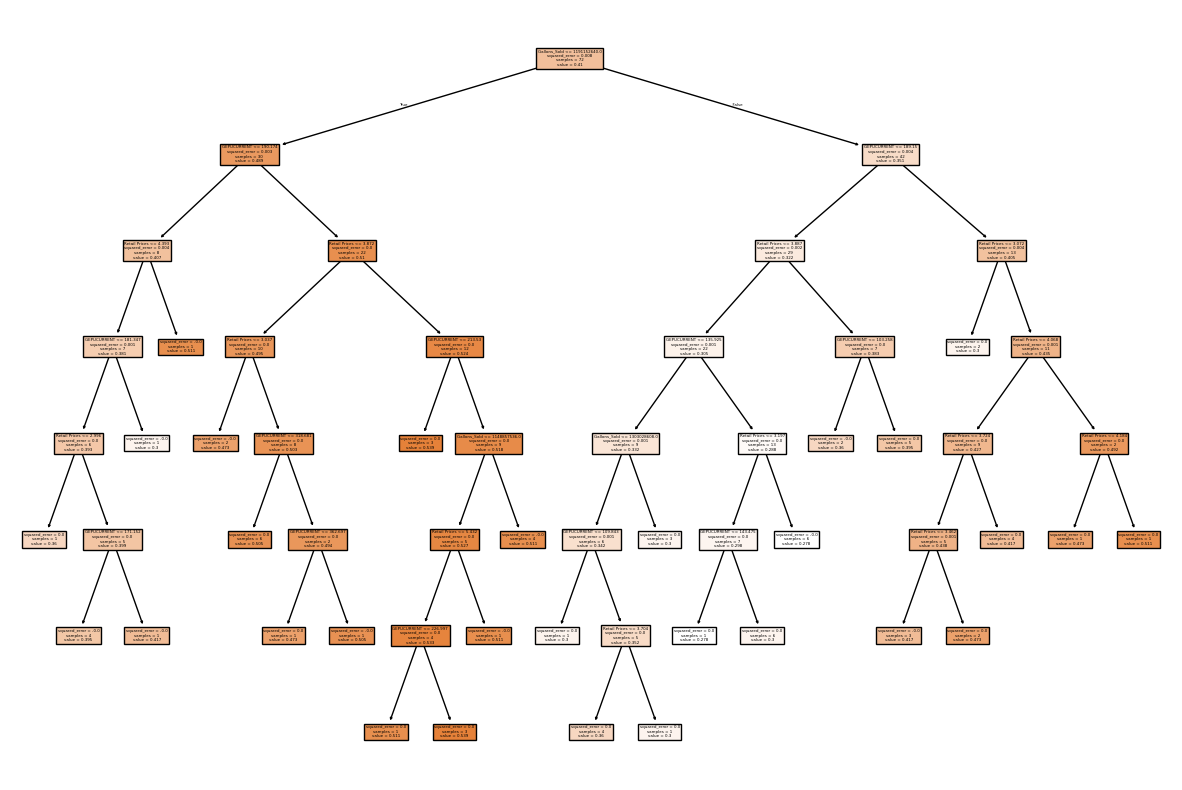

In [10]:
# Get one tree from the forest (e.g., the first one)
from sklearn import tree
import matplotlib.pyplot as plt
estimator_CA = rf_model_CA.estimators_[0]
plt.figure(figsize=(15,10))
tree.plot_tree(estimator_CA, feature_names=X_CA.columns, filled=True)
plt.show()

In [11]:
# A 5-fold cross-validation (R² score) on the random forest model
from sklearn.model_selection import cross_val_score
cross_scores_CA = cross_val_score(rf_model_CA, X_CA, y_CA, cv=5, scoring='r2')

print("Cross-validation R² scores (CA):", cross_scores_CA)
print("Mean R² (CA):", cross_scores_CA.mean())

Cross-validation R² scores (CA): [-4.62888935e+29 -2.75429805e-01 -7.32100580e-01 -1.59013800e+01
 -5.20190845e+00]
Mean R² (CA): -9.257778708265335e+28


In [12]:
# New Model, predicting retail prices based on tax rate
X_CA2 = CA[['CA_Tax_Rate']]
y_CA2 = CA['Retail Prices']
X_train_CA2, X_test_CA2, y_train_CA2, y_test_CA2 = train_test_split(X_CA2, y_CA2, test_size=0.2, random_state=42)
# Fit model and create predictions
model_CA2 = LinearRegression()
lin_model = model_CA2.fit(X_train_CA2, y_train_CA2)
y_pred_CA2 = model_CA2.predict(X_test_CA2)
lin_importance_CA2 = model_CA2.coef_
linreg_r2_CA2 = r2_score(y_test_CA2, y_pred_CA2)
linreg_RMSE_CA2 = mean_squared_error(y_test_CA2, y_pred_CA2)
print("R^2 Score (CA):", linreg_r2_CA2)
print("RMSE (CA):", linreg_RMSE_CA2)

R^2 Score (CA): 0.4722179427886919
RMSE (CA): 0.30230429825799926


In [13]:
#For correlated variables trying ridge and lasso models.
ridge_CA2 = Ridge(alpha=1.0)
y_ridge_CA2 = ridge_CA2.fit(X_train_CA2, y_train_CA2)
ridge_r2_CA2 = ridge_CA2.score(X_test_CA2, y_test_CA2)
print("Ridge R^2 (CA):", ridge_r2_CA2)
lasso_CA2 = Lasso(alpha=0.01)
y_lasso_CA2=lasso_CA2.fit(X_train_CA2, y_train_CA2)
y_lasso_pred_CA2 = lasso_CA2.predict(X_test_CA2)
lasso_importance_CA2 = lasso_CA2.coef_
lasso_r2_CA2 =  lasso_CA2.score(X_test_CA2, y_test_CA2)
lasso_RMSE_CA2 = mean_squared_error(y_test_CA2, y_lasso_pred_CA2)
print("R^2 Lasso (CA):", lasso_r2_CA2)
print("RMSE Lasso (CA):", lasso_RMSE_CA2)

Ridge R^2 (CA): 0.3405790656790083
R^2 Lasso (CA): 0.45157082432844253
RMSE Lasso (CA): 0.31413060529495196


In [14]:
#Random Forests are great when relationships are messy and not strictly linear.
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_CA2 = rf2.fit(X_train_CA2, y_train_CA2)
y_rf_pred_CA2 = rf2.predict(X_test_CA2)
rf_importance_CA2 = rf_model_CA2.feature_importances_
rf_r2_CA2 = r2_score(y_test_CA2, y_rf_pred_CA2)
rf_RMSE_CA2 = mean_squared_error(y_test_CA2, y_rf_pred_CA2)
print("Random Forest R^2:", rf_r2_CA2)
print("RMSE (Random Forest, CA):", rf_RMSE_CA2)

Random Forest R^2: 0.6614725067992281
RMSE (Random Forest, CA): 0.19390260596169864


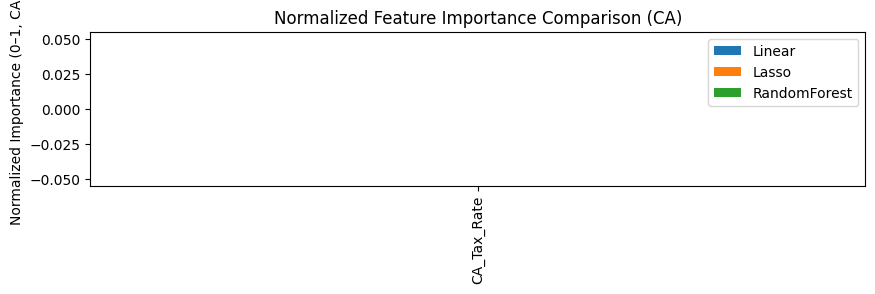

In [15]:
# Displaying normalized importance values
scaler_CA2 = MinMaxScaler()
all_importances_CA2 = pd.DataFrame({"Linear": lin_importance_CA2,
                                    "Lasso": lasso_importance_CA2,
                                    "RandomForest": rf_importance_CA2}, 
                                   index=X_CA2.columns)
normalized_CA2 = pd.DataFrame(scaler_CA2.fit_transform(all_importances_CA2),
                              columns=all_importances_CA2.columns,index=all_importances_CA2.index)
#Plot the normalized importance
normalized_CA2.plot(kind="bar", figsize=(10,2))
plt.title("Normalized Feature Importance Comparison (CA)")
plt.ylabel("Normalized Importance (0–1, CA)")
plt.show()

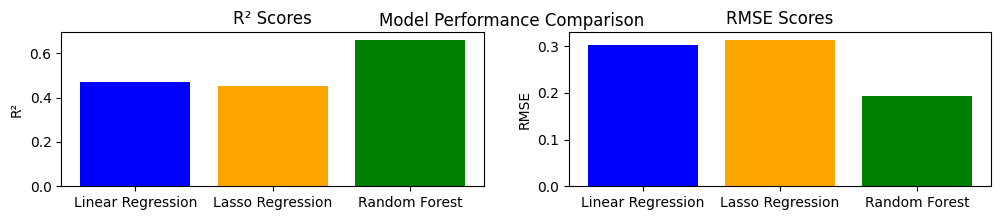

In [16]:
results2 = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression", "Random Forest"],
    "R2": [linreg_r2_CA2, lasso_r2_CA2, rf_r2_CA2],
    "RMSE": [linreg_RMSE_CA2, lasso_RMSE_CA2, rf_RMSE_CA2]})
fig, ax = plt.subplots(1, 2, figsize=(12,2))
ax[0].bar(results2["Model"], results2["R2"], color=["blue","orange","green"])
ax[0].set_title("R² Scores")
ax[0].set_ylabel("R²")
ax[1].bar(results2["Model"], results2["RMSE"], color=["blue","orange","green"])
ax[1].set_title("RMSE Scores")
ax[1].set_ylabel("RMSE")
plt.suptitle("Model Performance Comparison")
plt.show()

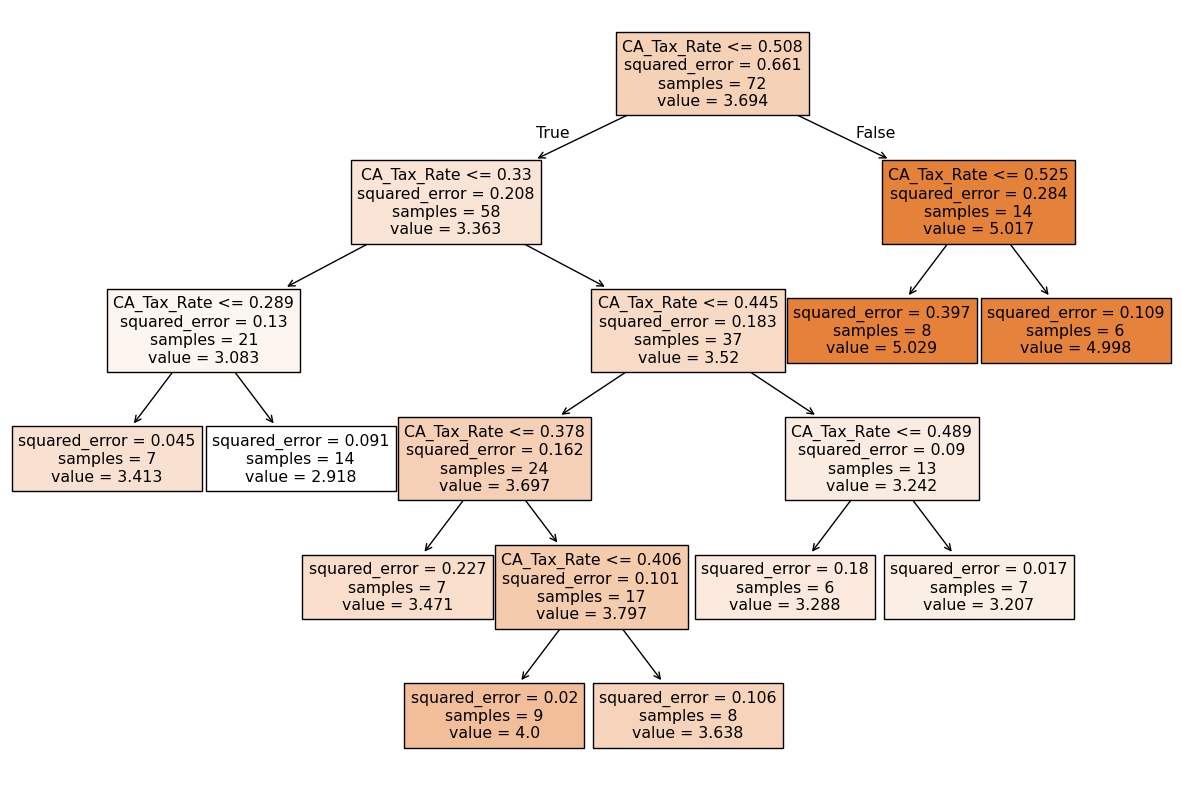

In [17]:
# Get one tree from the forest (e.g., the first one)
estimator_CA2 = rf_model_CA2.estimators_[0]
plt.figure(figsize=(15,10))
tree.plot_tree(estimator_CA2, feature_names=X_CA2.columns, filled=True)
plt.show()

In [18]:
# A 5-fold cross-validation (R² score) on the random forest model
cross_scores_CA2 = cross_val_score(rf_model_CA2, X_CA2, y_CA2, cv=5, scoring='r2')
print("Cross-validation R² scores (CA):", cross_scores_CA2)
print("Mean R² (CA):", cross_scores_CA2.mean())

Cross-validation R² scores (CA): [-6.56797154e-03 -2.42179965e-01 -1.08675351e+00 -1.16192111e+01
 -2.36477991e+00]
Mean R² (CA): -3.0638984844072334
